In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import tqdm
import helpers

import environments
import environments.bicycle as bicycle

import controllers.dqn as dqn
import controllers.ppo as ppo
import controllers.clothoids as clothoids
import controllers.purepursuit as purepursuit

import metrics

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

/Users/nadir/Documents/research-project/.venv.mac/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
objc[2515]: Class SDLApplication is implemented in both /Users/nadir/Documents/research-project/.venv.mac/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x10eeed2c8) and /Users/nadir/Documents/research-project/.venv.mac/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x168164890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[2515]: Class SDLAppDelegate is implemented in both /Users/nadir/Documents/research-project/.venv.mac/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dyl

In [3]:
env = environments.bicycle.BicycleCarEnv(
    road_network=bicycle.RoadNetwork(roads=[
        bicycle.create_rectangular_track(
            center=(50.0, 50.0),
            length=80.0,
            height=40.0,
            turn_radius=8.0,
            width=8.0,
        )
    ]),
    render_mode="rgb_array",
    spawn=((50.0, 30.0), 0.0),
    goal=((10.0, 50.0), 2.0),
    obstacles=[
        bicycle.Circle(center=(90, 50), radius=1.0),
    ],
    solid_road_borders=True,
    # 0.1second = 100ms per step
    dt=0.1
)

In [4]:
controller = clothoids.ClothoidTentaclesController(
    num_tentacles=41,
    # t0=7.0,
    t0=10.0,
    # l0=5.0,
    l0=10.0,
    num_points_per_tentacle=64,

    wheelbase=env.WHEELBASE,
    vehicle_width=env.CAR_WIDTH,
    max_lateral_acceleration=4.0,
    max_deceleration=1.5,

    # clearance, curvature, trajectory
    weights=(0.1, 0.2, 0.5),

    # TODO: I set a target velocity of 3.5 but the controller always goes at 5.0 m/s
    target_velocity=3.5,
    kp_velocity=2.0,
)

In [ ]:
environments.bicycle.wrappers.observations.WithObstaclesInfo
environments.bicycle.wrappers.observations.WithDynamicsInfo
environments.bicycle.wrappers.observations.WithPathInfo
environments.bicycle.wrappers.observations.WithRoadInfo

In [ ]:
wrappers = lambda env: environments.bicycle.wrappers.observations.WithObstaclesInfo(
    environments.bicycle.wrappers.observations.WithPathInfo(
        environments.bicycle.wrappers.observations.WithRoadInfo(
            environments.bicycle.wrappers.observations.WithDynamicsInfo(
                env
            )
        )
    )
)

[env.observation_space]: Dict('base/heading': Box(-3.1415927, 3.1415927, (1,), float32), 'base/position': Box(-inf, inf, (2,), float32), 'base/velocity': Box(-15.0, 15.0, (1,), float32))
[env.action_space]: Box([-0.7853982  0.         0.         0.       ], [0.7853982 1.        1.        1.       ], (4,), float32)
[path.#points]: 557
[observation]: dict_keys(['base/position', 'base/heading', 'base/velocity'])


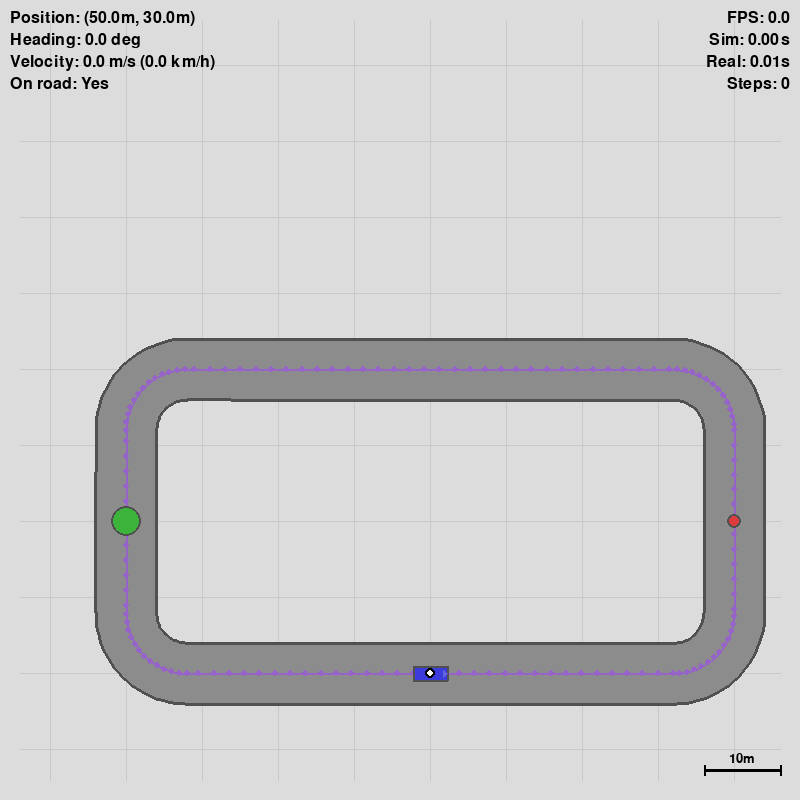

In [14]:
env = environments.bicycle.BicycleCarEnv(
    road_network=bicycle.RoadNetwork(roads=[
        bicycle.create_rectangular_track(
            center=(50.0, 50.0),
            length=80.0,
            height=40.0,
            turn_radius=8.0,
            width=8.0,
        )
    ]),
    render_mode="rgb_array",
    spawn=((50.0, 30.0), 0.0),
    goal=((10.0, 50.0), 2.0),
    obstacles=[
        bicycle.Circle(center=(90, 50), radius=1.0),
    ],
    solid_road_borders=True,
    # 0.1second = 100ms per step
    dt=0.1
)

# TODO: what if we apply this twice ? I hope it is the same as applying it once
# env = environments.bicycle.wrappers.actions.MultiDiscreteActionWrapper(env)

env = environments.bicycle.wrappers.observations.WithBaseInfo(env)
# env = environments.bicycle.wrappers.observations.WithObstaclesInfo(env)
# env = environments.bicycle.wrappers.observations.WithPathInfo(env)
# env = environments.bicycle.wrappers.observations.WithRoadInfo(env)
# env = environments.bicycle.wrappers.observations.WithDynamicsInfo(env)

print("[env.observation_space]:", env.observation_space)
print("[env.action_space]:", env.action_space)

print("[path.#points]:", len(env.unwrapped.path))
# print("[path[:10]]:", env.unwrapped.path[:10])

observation, info = env.reset()

print("[observation]:", observation.keys())

helpers.preview(env, False)

In [ ]:
# TODO: start simple, using the base info wrapper teach the model to drive, it'll learn 100% the track and will take time, no generalization
# TODO: progressively add more info to the observation space and see how it improves generalization

In [ ]:
env = environments.bicycle.BicycleCarEnv(
    road_network=bicycle.RoadNetwork(roads=[
        bicycle.create_rectangular_track(
            center=(50.0, 50.0),
            length=80.0,
            height=40.0,
            turn_radius=8.0,
            width=8.0,
        )
    ]),
    render_mode="rgb_array",
    spawn=((50.0, 30.0), 0.0),
    goal=((10.0, 50.0), 2.0),
    obstacles=[
        bicycle.Circle(center=(90, 50), radius=1.0),
    ],
    solid_road_borders=True,
    # 0.1second = 100ms per step
    dt=0.1
)

# env = environments.bicycle.wrappers.rewards.CombinedReward(env)
env = environments.bicycle.wrappers.rewards.SimpleRewardWrapper(env)

env = environments.bicycle.wrappers.observations.WithBaseInfo(env)
env = environments.bicycle.wrappers.observations.WithObstaclesInfo(env)
env = environments.bicycle.wrappers.observations.WithPathInfo(env)
env = environments.bicycle.wrappers.observations.WithRoadInfo(env)
env = environments.bicycle.wrappers.observations.WithDynamicsInfo(env)

# env = environments.bicycle.wrappers.actions.MultiDiscreteActionWrapper(env)
# env = environments.bicycle.wrappers.actions.FlattenMultiDiscreteWrapper(env)

env = gym.wrappers.TimeLimit(env, max_episode_steps=500)

controller = ppo.PPOController(
    env,
    model_kwargs={
        'learning_rate': 3e-4,
        'n_steps': 2048,
        'batch_size': 64,
        'n_epochs': 10,
        'verbose': 1
    }
)

In [ ]:
print(env.action_space.shape)
print(env.observation_space.keys())

In [ ]:
controller.model.logger.name_to_value.get("time/episodes")

In [ ]:
from stable_baselines3.common.callbacks import ProgressBarCallback

controller = controller.train(
    total_timesteps=1_000_000,
    log_interval=4,
    # callback=lambda a, b: print(a) and True
)

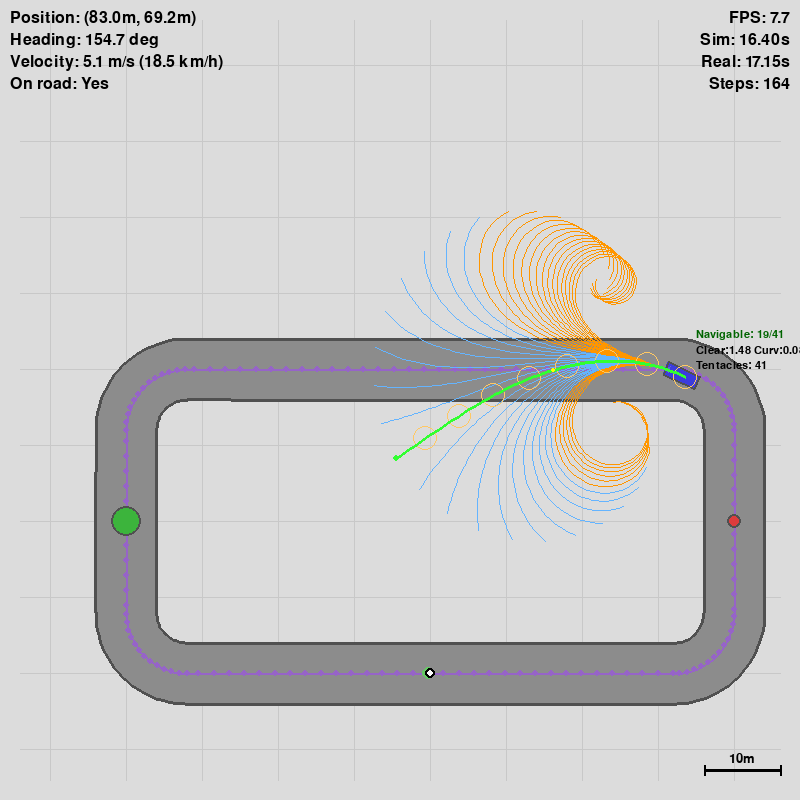

KeyboardInterrupt: 

In [18]:
obs, info = env.reset()

for i in range(500):
    # TODO: what are the _states ?
    action, _states = controller.get_action(
        observation=obs,
        path=env.unwrapped.path,
        obstacles=env.unwrapped.obstacles,
        road_network=env.unwrapped.road_network,
        max_steering=env.unwrapped.MAX_STEERING,
        max_acceleration=env.unwrapped.MAX_ACCELERATION,
    )
    
    print(action)
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.unwrapped.overlay_manager.clear()
    controller.draw_debug(env, obs, env.unwrapped.path)
    
    helpers.preview(env)

    if terminated or truncated:
        break

env.close()

In [ ]:
# Get episode data and compute metrics
episode_data = env.get_episode_data()
# print(f"Episode finished after {i+1} steps")

# Compute metrics
print("\n=== Performance Metrics ===")

cte_metrics = metrics.compute_cross_track_error(
    positions=episode_data['positions'],
    reference_path=env.path,
)
print(f"CTE RMS: {cte_metrics['cte_rms']:.3f} m")

smoothness_metrics = metrics.compute_steering_smoothness(
    steering_angles=episode_data['steering_angles'],
    dt=env.unwrapped.DELTA_TIME
)
print(f"Steering Jerk RMS: {smoothness_metrics['steering_jerk_rms']:.3f} rad/s³")

success = metrics.compute_success_rate([episode_data])
print(f"Success: {'Yes' if success == 1.0 else 'No'}")